## Week 2

Emotion Counts:
neutral: 96
calm: 192
happy: 192
sad: 192
angry: 192
fearful: 192
disgust: 192
surprised: 192


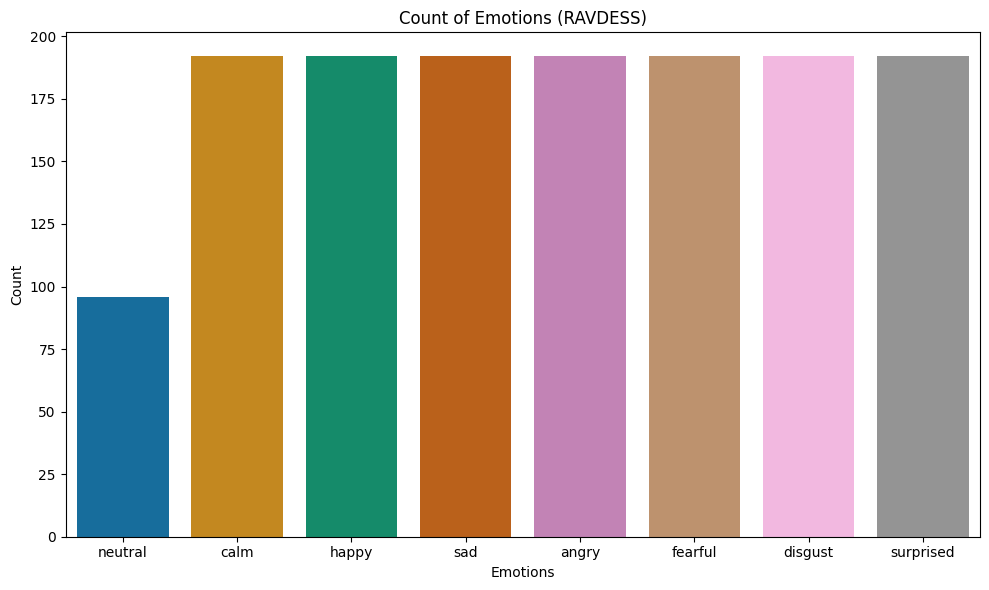

In [26]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Đường dẫn tới thư mục chứa tập dữ liệu
ravdess_path = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/**/*.wav"

# Mapping RAVDESS numeric encoding to emotions
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Extract emotion labels from filenames
filenames = glob.glob(ravdess_path, recursive=True)
emotions = [emotion_map[os.path.basename(f).split('-')[2]] for f in filenames if os.path.basename(f).split('-')[2] in emotion_map]

# Count occurrences of each emotion
emotion_counts = Counter(emotions)

# Sort emotions by predefined order
emotion_order = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
counts = [emotion_counts[e] for e in emotion_order if e in emotion_counts]

# Print the count of each emotion
print("Emotion Counts:")
for emotion in emotion_order:
    count = emotion_counts.get(emotion, 0)
    print(f"{emotion}: {count}")

# Plot the emotion distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=pd.Series(emotion_order), y=counts, palette="colorblind")
plt.xlabel("Emotions")
plt.ylabel("Count")
plt.title("Count of Emotions (RAVDESS)")
plt.tight_layout()
plt.show()



In [27]:
# Hàm chuẩn hóa âm thanh
def normalize_audio(data):
    return librosa.util.normalize(data)

# Hàm trích xuất đặc trưng
def extract_features(data, sampling_rate, n_mfcc=8):
    mfccs = librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=n_mfcc).mean(axis=1)
    chroma = librosa.feature.chroma_stft(y=data, sr=sampling_rate).mean(axis=1)
    spectral_centroid = librosa.feature.spectral_centroid(y=data, sr=sampling_rate).mean()
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=data, sr=sampling_rate).mean()
    return np.hstack((mfccs, chroma, [spectral_centroid], [spectral_bandwidth]))

# Thư mục chứa file âm thanh
audio_folder = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"  # Cập nhật đường dẫn đúng

# Dữ liệu huấn luyện
X = []  # input
y = []  # label
plotdata = []
# Duyệt qua tất cả các file trong thư mục
for root, dirs, files in os.walk(audio_folder):
    for filename in files:
        if filename.endswith(".wav"):
            file_path = os.path.join(root, filename)
    
            # Tải âm thanh
            data, sampling_rate = librosa.load(file_path, sr=None)
            data = normalize_audio(data)
            
            # Trích xuất đặc trưng
            features = extract_features(data, sampling_rate)
            
            # Lấy nhãn từ tên file (số thứ 3 trong tên file)
            label = filename.split("-")[2]  # Lấy phần tử thứ 3 (index 2)
            
            # Chọn mẫu đầu tiên để in ra biểu đồ 
            if label not in y:
                plotdata.append([data, sampling_rate])
                
            # Lưu vào danh sách
            X.append(features)
            y.append(label)

# Chuyển X thành DataFrame
feature_names = [f"mfcc_{i}" for i in range(8)] + \
                [f"chroma_{i}" for i in range(12)] + \
                ["spectral_centroid", "spectral_bandwidth"]

features_df = pd.DataFrame(X, columns=feature_names)
features_df['label'] = y 

# Lưu thành CSV
features_df.to_csv("audio_features.csv", index=False)
print("✅ Feature extraction completed and saved to audio_features.csv.")


✅ Feature extraction completed and saved to audio_features.csv.


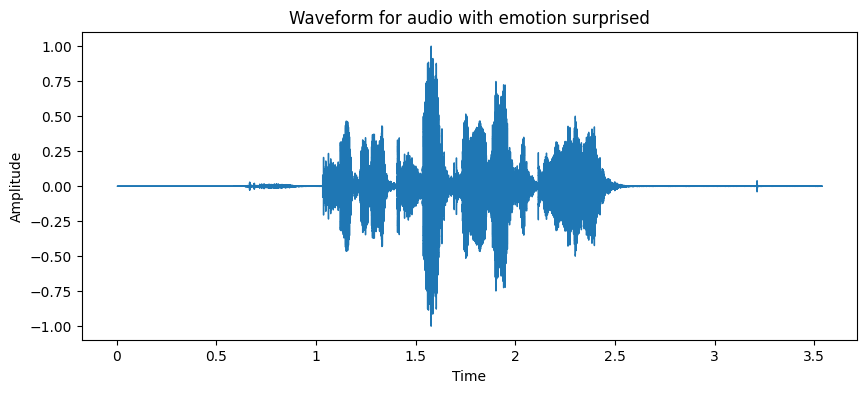

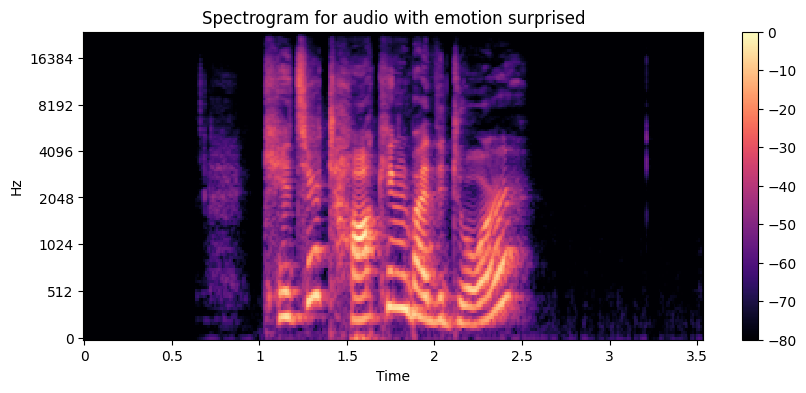

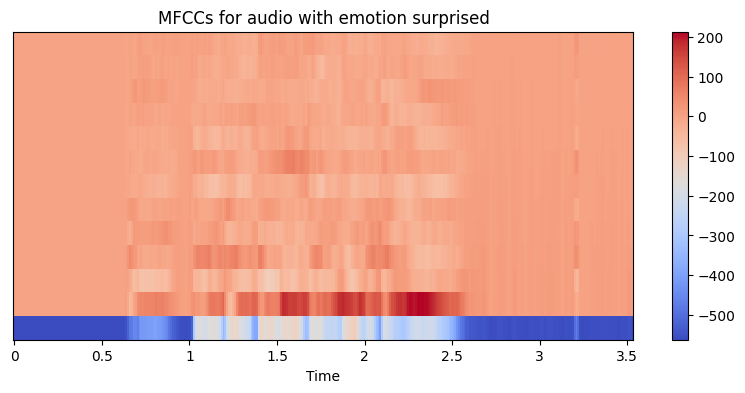

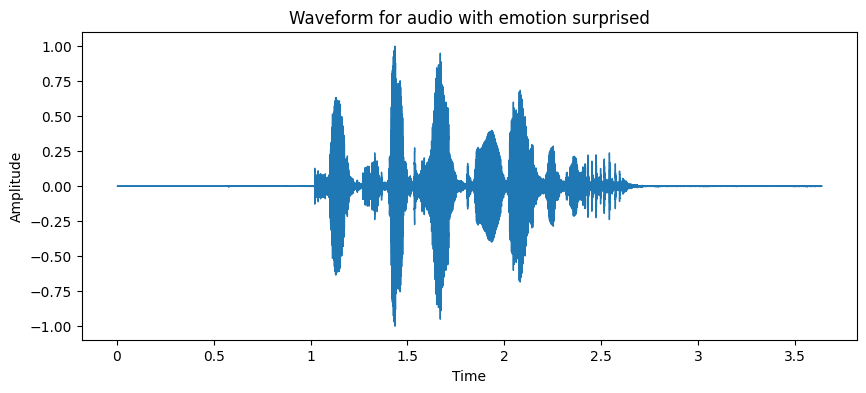

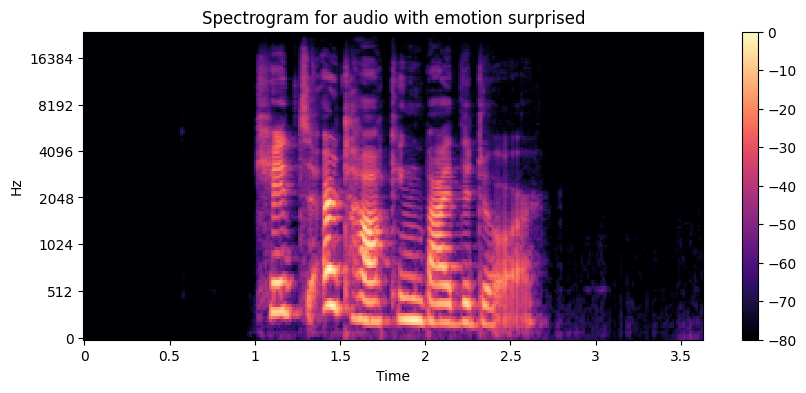

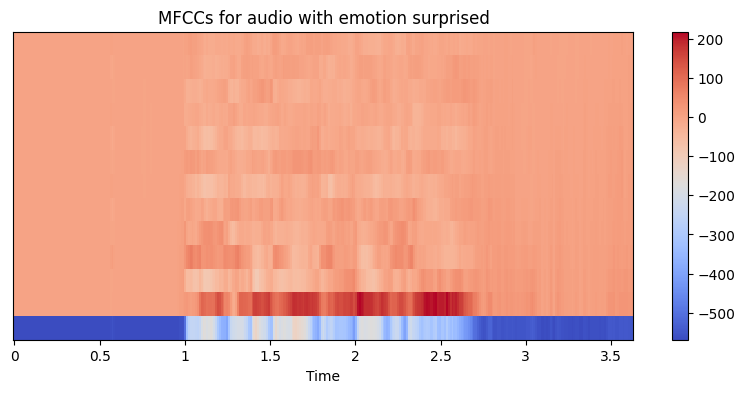

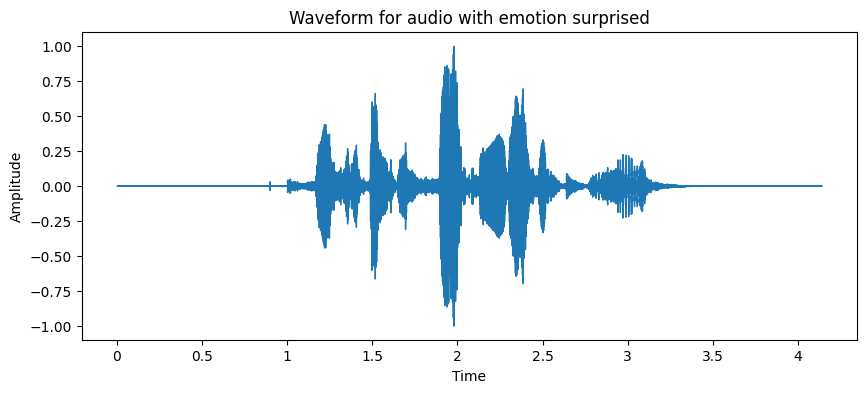

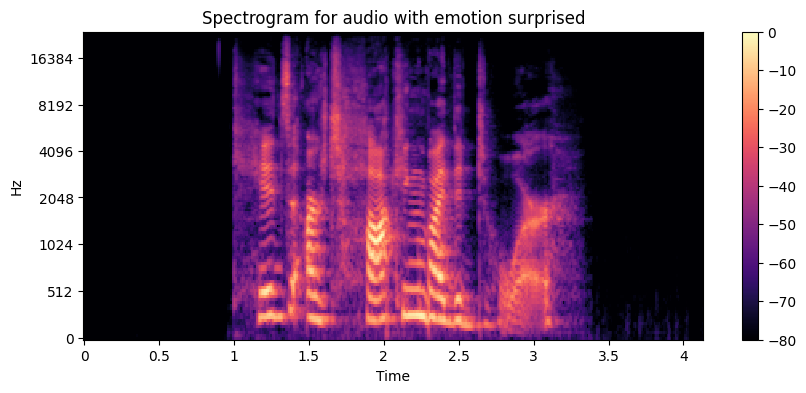

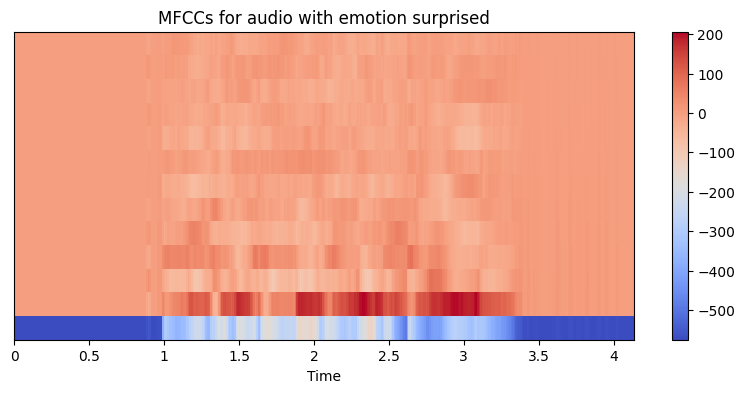

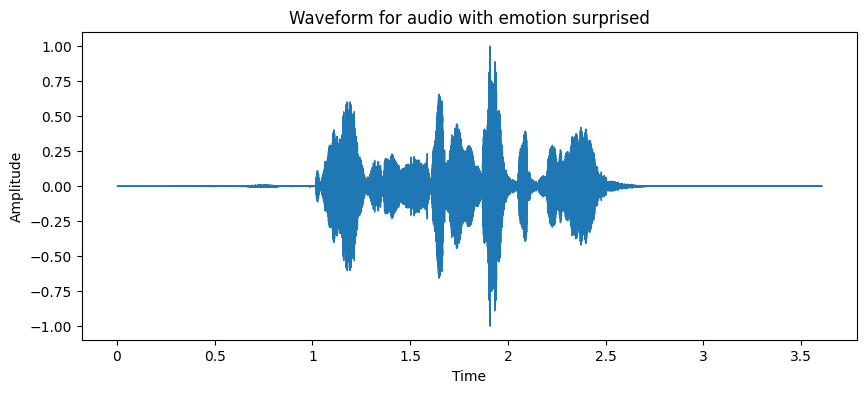

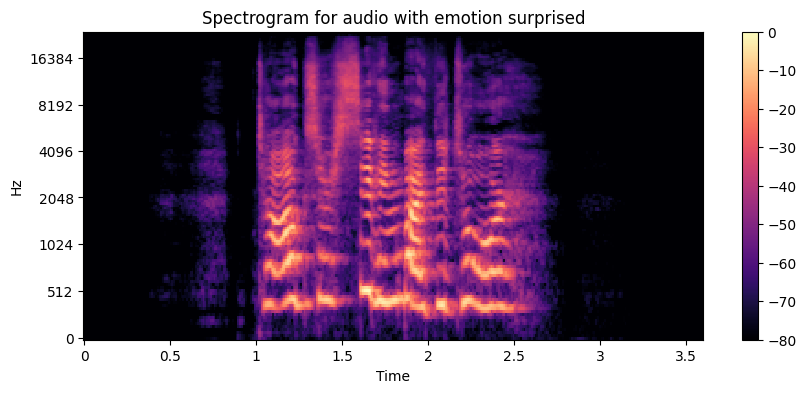

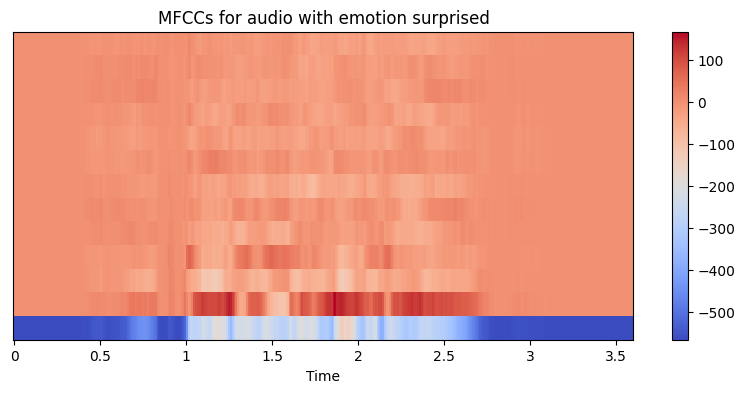

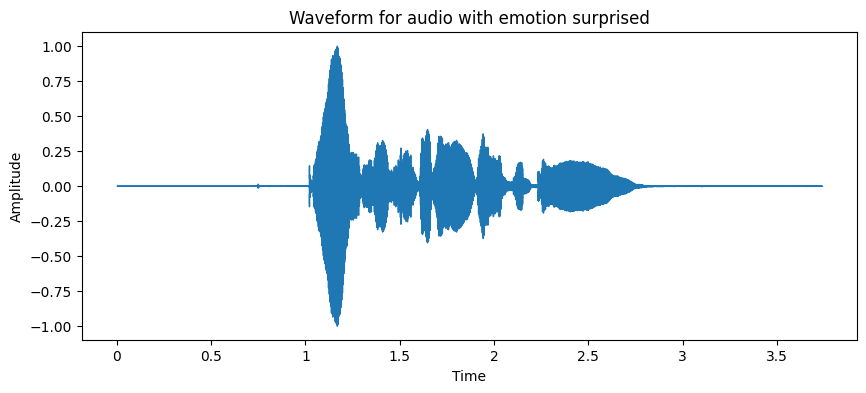

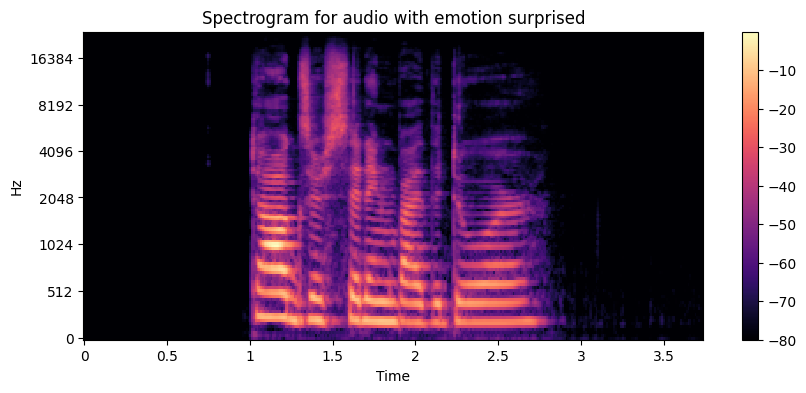

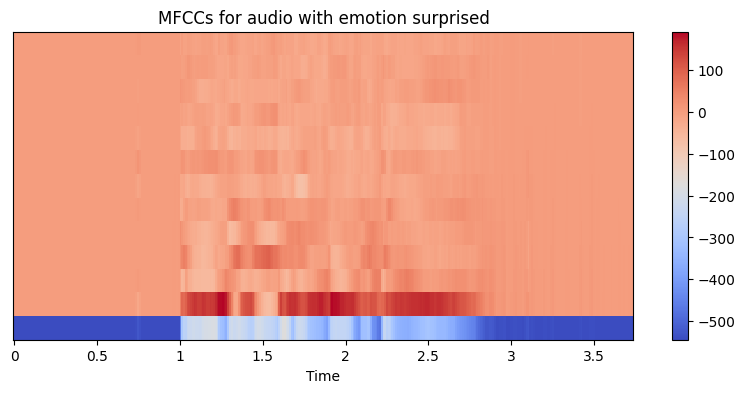

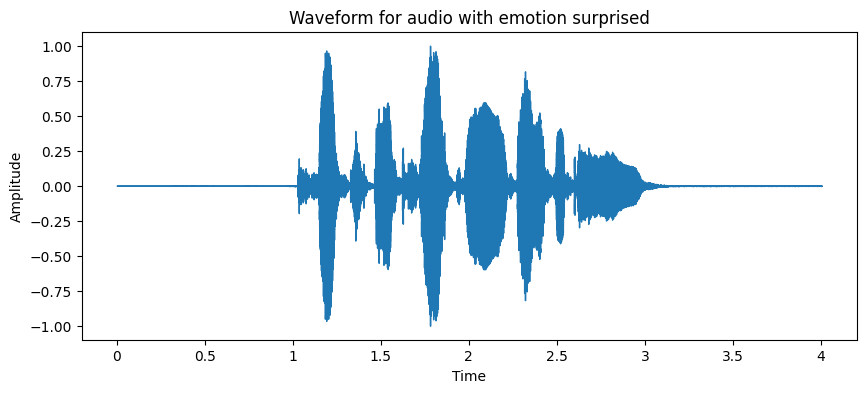

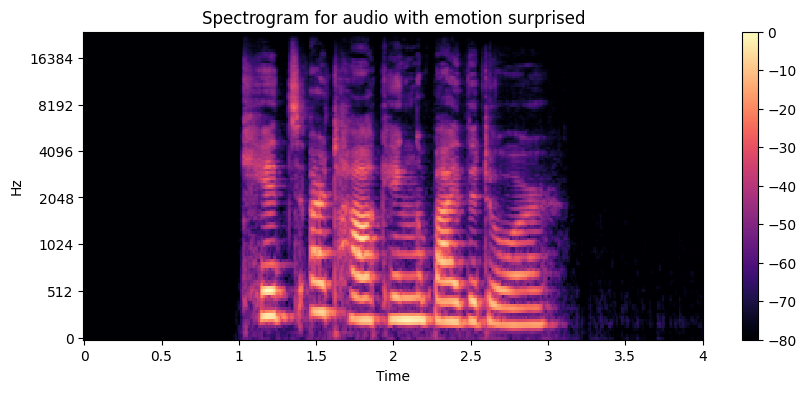

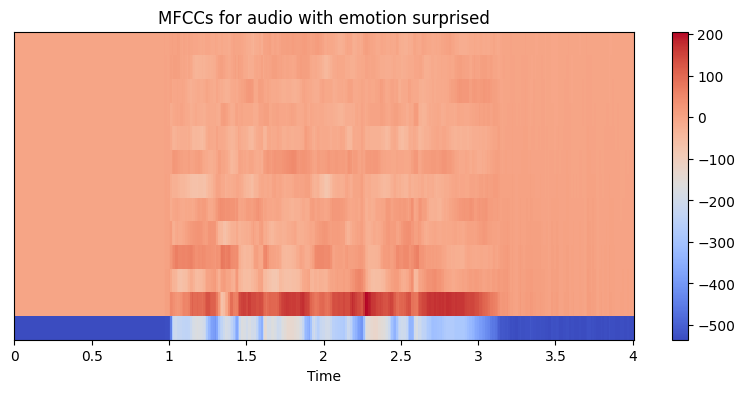

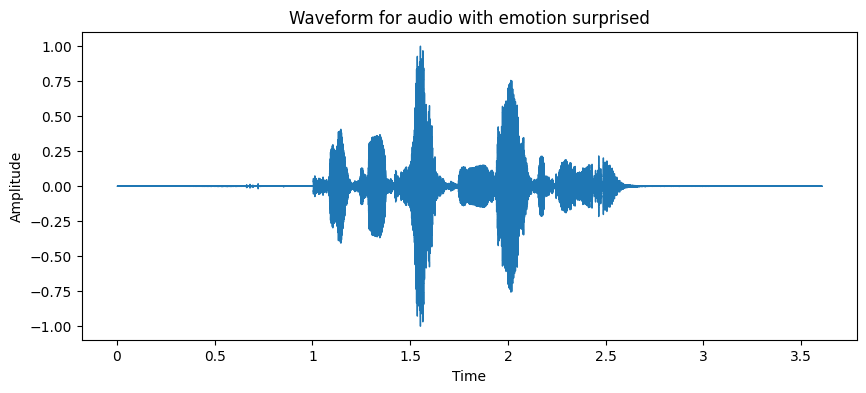

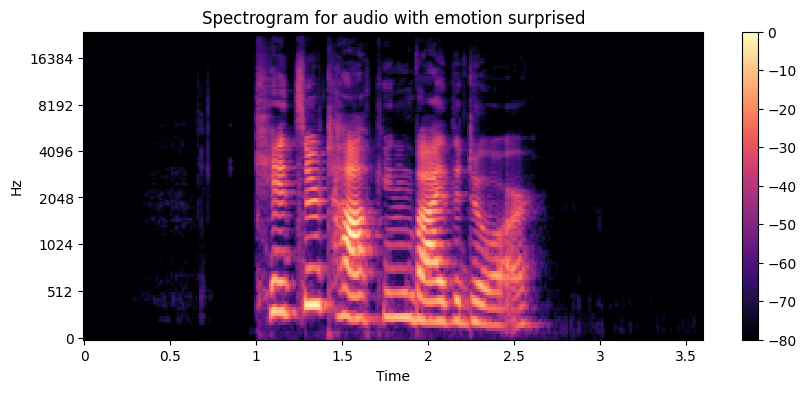

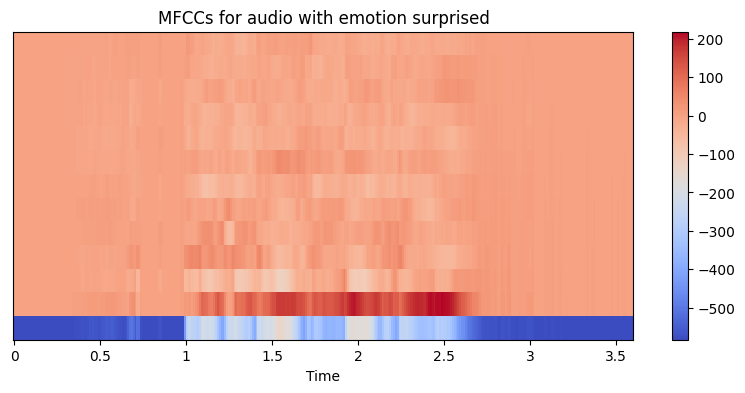

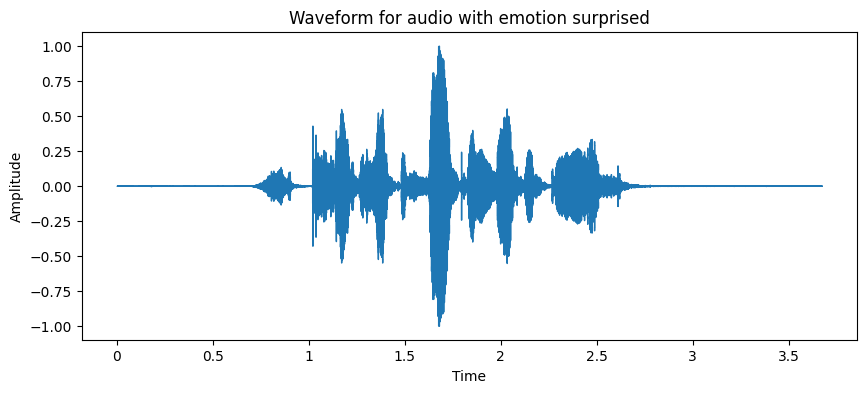

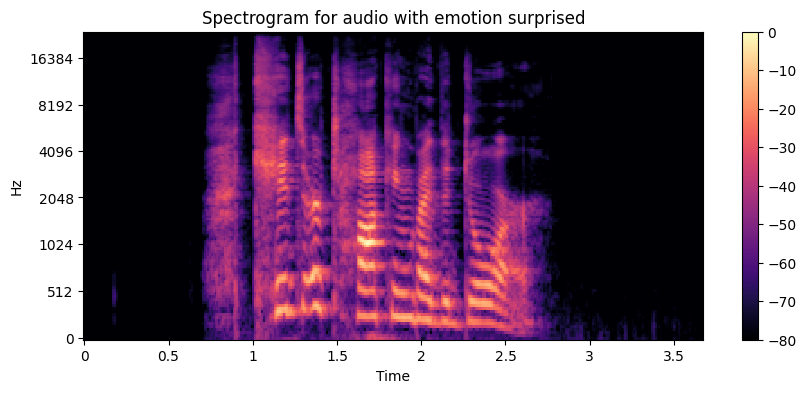

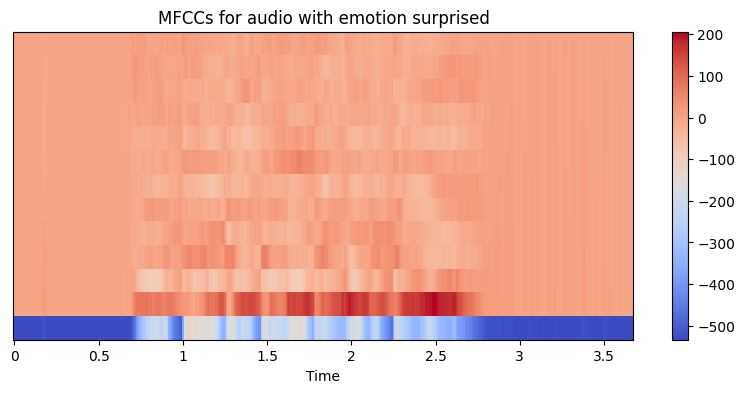

In [31]:


# Xử lý từng input theo cảm xúc riêng biệt
for data in plotdata:
    
        
        data, sampling_rate = data 
        
        # Hiển thị các đồ thị
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(data, sr=sampling_rate)
        plt.title(f"Waveform for audio with emotion {emotion}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.show()
        
        plt.figure(figsize=(10, 4))
        S = librosa.feature.melspectrogram(y=data, sr=sampling_rate)
        S_DB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_DB, sr=sampling_rate, x_axis='time', y_axis='mel')
        plt.colorbar()
        plt.title(f"Spectrogram for audio with emotion {emotion}")
        plt.show()
        
        plt.figure(figsize=(10, 4))
        mfccs = librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=13)
        librosa.display.specshow(mfccs, sr=sampling_rate, x_axis='time')
        plt.colorbar()
        plt.title(f"MFCCs for audio with emotion {emotion}")
        plt.show()






In [29]:

df = pd.read_csv("audio_features.csv")
df


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,chroma_0,chroma_1,...,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,spectral_centroid,spectral_bandwidth,label
0,-403.439301,56.227074,-14.788618,5.832397,-0.544787,1.759662,-13.963181,3.950096,0.418964,0.407613,...,0.433930,0.434542,0.438518,0.442731,0.442625,0.485596,0.451922,4882.274244,4355.148364,8
1,-424.082672,68.959435,-4.962604,5.423140,0.609843,3.160730,-9.528842,2.647468,0.407521,0.370773,...,0.443065,0.473625,0.490757,0.471405,0.416871,0.402151,0.397698,4876.754830,4398.780657,1
2,-411.816132,67.389900,-13.988151,8.438960,-4.720516,-2.079224,-7.776217,2.852065,0.516496,0.477249,...,0.543188,0.561185,0.510913,0.508345,0.503080,0.529001,0.530643,5711.782215,4570.489908,7
3,-396.781708,79.525726,-12.700561,8.421184,-1.814424,-0.365204,-5.796456,1.607945,0.357673,0.301923,...,0.421796,0.486942,0.462681,0.458054,0.417134,0.413995,0.389177,3880.661643,3724.379799,7
4,-423.729431,64.622581,-5.608734,3.477045,-2.100554,2.704671,-9.134014,2.263086,0.456362,0.457200,...,0.562676,0.582794,0.569819,0.522362,0.504564,0.551401,0.523599,6271.879991,5041.196816,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-384.545044,77.826782,-6.234526,11.061896,1.893061,13.460345,-10.770215,-5.606112,0.470809,0.444220,...,0.468663,0.536554,0.593239,0.651385,0.582784,0.503584,0.465162,5448.254984,5314.909927,6
1436,-360.491699,67.595528,-4.397058,16.146326,3.479628,9.014054,-12.870681,1.016159,0.489763,0.505064,...,0.502447,0.531487,0.535349,0.517293,0.519698,0.518658,0.517687,5247.098966,4554.625677,5
1437,-364.057251,94.717918,-5.434953,11.034218,6.998950,20.168148,-11.770555,-9.371555,0.529389,0.492917,...,0.424603,0.462852,0.476607,0.507812,0.540740,0.489127,0.474805,4647.894445,4790.763324,4
1438,-377.700134,67.164177,7.213645,29.855272,1.011643,14.839088,-13.544244,0.196340,0.424044,0.432793,...,0.514376,0.532318,0.532196,0.557028,0.516795,0.488662,0.447107,5407.159334,5026.928580,7


In [30]:
import os

# Tìm tệp CSV trong thư mục làm việc
csv_files = [f for f in os.listdir("/kaggle/working/") if f.endswith(".csv")]

# In ra danh sách các tệp CSV tìm thấy
print("Các tệp CSV trong thư mục làm việc:")
for file in csv_files:
    print(f"- {file}")

# Kiểm tra đường dẫn đầy đủ
if csv_files:
    print("\nĐường dẫn đầy đủ:")
    for file in csv_files:
        print(f"/kaggle/working/{file}")
else:
    print("Không tìm thấy tệp CSV nào trong thư mục làm việc.")


Các tệp CSV trong thư mục làm việc:
- audio_features.csv

Đường dẫn đầy đủ:
/kaggle/working/audio_features.csv
